Distances: [4, 9, 13, 20, 13, 18]

Best Chromosome: [1, 0, 1, 1, 0, 0]
Vehicle 1 distance: 40
Vehicle 2 distance: 37
Difference: 3


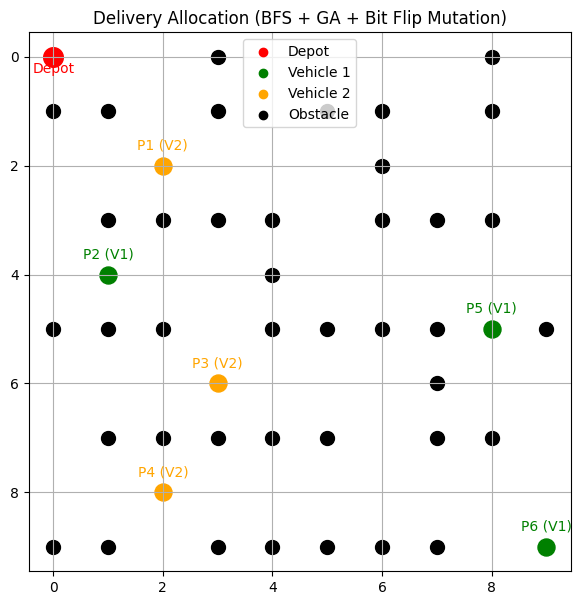

In [1]:
import random
import matplotlib.pyplot as plt
from collections import deque

ROWS, COLS = 10, 10

grid = [
    [0,0,0,1,0,0,0,0,1,0],
    [1,1,0,1,0,1,1,0,1,0],
    [0,0,0,0,0,0,1,0,0,0],
    [0,1,1,1,1,0,1,1,1,0],
    [0,0,0,0,1,0,0,0,0,0],
    [1,1,1,0,1,1,1,1,0,1],
    [0,0,0,0,0,0,0,1,0,0],
    [0,1,1,1,1,1,0,1,1,0],
    [0,0,0,0,0,0,0,0,0,0],
    [1,1,0,1,1,1,1,1,0,0]
]

depot = (0, 0)

points = [
    (2, 2),
    (4, 1),
    (6, 3),
    (8, 2),
    (5, 8),
    (9, 9)
]


def bfs(start, goal):
    queue = deque([(start, 0)])
    visited = set([start])

    directions = [(1,0), (-1,0), (0,1), (0,-1)]

    while queue:
        (x, y), dist = queue.popleft()

        if (x, y) == goal:
            return dist

        for dx, dy in directions:
            nx, ny = x + dx, y + dy

            if 0 <= nx < ROWS and 0 <= ny < COLS:
                if grid[nx][ny] == 0 and (nx, ny) not in visited:
                    visited.add((nx, ny))
                    queue.append(((nx, ny), dist + 1))

    return 999

distances = [bfs(depot, p) for p in points]
print("Distances:", distances)


def fitness(chromosome):
    v1, v2 = 0, 0

    for i in range(len(chromosome)):
        if chromosome[i] == 0:
            v1 += distances[i]
        else:
            v2 += distances[i]

    return abs(v1 - v2)


#عدد الـ chromosomes في كل population = 20.
POP_SIZE = 20

# عدد الـ generations = 60.
GENERATIONS = 60

# احتمال حدوث mutation = 20%.

# يعني:
# فيه فرصة 20% إن gene يتغير.
MUTATION_RATE = 0.2

# دي function وظيفتها:
# إنشاء أول population عشوائي.
def create_population():
    return [[random.randint(0,1) for _ in range(6)] for _ in range(POP_SIZE)]


def selection(pop):
    return sorted(pop, key=lambda x: fitness(x))[:2]


def crossover(p1, p2):
    point = random.randint(1, 5)
    return p1[:point] + p2[point:]


def mutation(chrom):
    if random.random() < MUTATION_RATE:
        idx = random.randint(0, 5)
        chrom[idx] = 1 - chrom[idx]  # flip 0 <-> 1
    return chrom


population = create_population()

for _ in range(GENERATIONS):
    parents = selection(population)
    # بنخزن فيها افضل اتنين كروموسوم في كل جيل
    new_pop = parents.copy()

    while len(new_pop) < POP_SIZE:
        child = crossover(parents[0], parents[1])
        child = mutation(child)
        new_pop.append(child)

    population = new_pop

best = min(population, key=lambda x: fitness(x))


v1, v2 = 0, 0

for i in range(6):
    if best[i] == 0:
        v1 += distances[i]
    else:
        v2 += distances[i]

print("\nBest Chromosome:", best)
print("Vehicle 1 distance:", v1)
print("Vehicle 2 distance:", v2)
print("Difference:", abs(v1 - v2))


def plot():
    plt.figure(figsize=(7,7))

    # obstacles
    for i in range(ROWS):
        for j in range(COLS):
            if grid[i][j] == 1:
                plt.scatter(j, i, color='black', s=100)

    # depot
    plt.scatter(depot[1], depot[0], color='red', s=200)
    plt.text(depot[1], depot[0]+0.3, "Depot", ha='center', color='red')

    # points
    for i, p in enumerate(points):
        x, y = p

        if best[i] == 0:
            color = 'green'
            label = "V1"
        else:
            color = 'orange'
            label = "V2"

        plt.scatter(y, x, color=color, s=150)
        plt.text(y, x-0.3, f"P{i+1} ({label})", ha='center', color=color)

    plt.scatter([], [], color='red', label='Depot')
    plt.scatter([], [], color='green', label='Vehicle 1')
    plt.scatter([], [], color='orange', label='Vehicle 2')
    plt.scatter([], [], color='black', label='Obstacle')

    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.legend()
    plt.title("Delivery Allocation (BFS + GA + Bit Flip Mutation)")
    plt.show()

plot()